# Beijing's Air Quality After the 2013 Clean Air Action Plan
**Part 1 Temporal Structure and Climatology**

In 2013, China launched the Air Pollution Prevention and Control Action Plan, a major national clean-air program that set targets to reduce coal use and fine-particulate pollution in key regions through 2017.

**Aim:** to test whether Beijing's air quality improved over this period, and if so, which pollutant shows the clearest improvement once seasonality and weather are accounted for.

**Hypothesis:** coal-linked SO2 fell sharply and steadily, while PM2.5 improved more modestly and was partly hidden by year-to-year swings in the weather.

**Data:** hourly observations from twelve stations between March 2013 and February 2017, covering six pollutants alongside co-located meteorology, loaded directly from the UCI Machine Learning Repository. Only 2014, 2015, and 2016 are complete calendar years, which limits how the endpoints can be compared.

In [1]:
import io, zipfile, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

url = "https://archive.ics.uci.edu/static/public/501/beijing+multi+site+air+quality+data.zip"
r = requests.get(url, timeout=60)
r.raise_for_status()
outer = zipfile.ZipFile(io.BytesIO(r.content))
inner_name = [n for n in outer.namelist() if n.lower().endswith(".zip")][0]
inner = zipfile.ZipFile(io.BytesIO(outer.read(inner_name)))
frames = [pd.read_csv(inner.open(n)) for n in inner.namelist() if n.lower().endswith(".csv")]
df = pd.concat(frames, ignore_index=True)
df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]])
df = df.set_index("datetime").sort_index()

season_map = {12: "DJF", 1: "DJF", 2: "DJF", 3: "MAM", 4: "MAM", 5: "MAM",
              6: "JJA", 7: "JJA", 8: "JJA", 9: "SON", 10: "SON", 11: "SON"}
df["season"] = df["month"].map(season_map)

## Coverage and scale of variation

Before characterizing the cycles, a look at what the record contains: its temporal span, the number of stations, the extent of missing data, and, as a yardstick for everything that follows, how far the annual mean actually moves across the three complete calendar years. The full-year means fall from about 86 to 72 µg/m³ over 2014–2016. This range matters because the seasonal and daily cycles characterized below are larger than the year-to-year change, so a trend cannot be read directly from raw annual averages.

In [2]:
print("coverage:", df.index.min(), "->", df.index.max())
print("stations:", df["station"].nunique())
print("missing fraction:")
print(df[["PM2.5", "SO2", "NO2", "PM10"]].isna().mean().round(3))
print("full-year mean PM2.5, complete years:")
print(df[df["year"].isin([2014, 2015, 2016])].groupby("year")["PM2.5"].mean().round(1))

coverage: 2013-03-01 00:00:00 -> 2017-02-28 23:00:00
stations: 12
missing fraction:
PM2.5    0.021
SO2      0.021
NO2      0.029
PM10     0.015
dtype: float64
full-year mean PM2.5, complete years:
year
2014    85.6
2015    79.6
2016    71.9
Name: PM2.5, dtype: float64


## Diurnal cycle by season

PM2.5 does not rise and fall uniformly through the day, and the shape of its daily cycle depends on the season. Winter has both the highest concentrations and the strongest evening-to-night accumulation, consistent with a shallow, stable nocturnal boundary layer that traps heating-related emissions. Summer is lower and flatter. The winter daily amplitude alone is larger than the interannual spread of full-year means seen above, which is why the seasonal and diurnal cycles cannot be set aside.

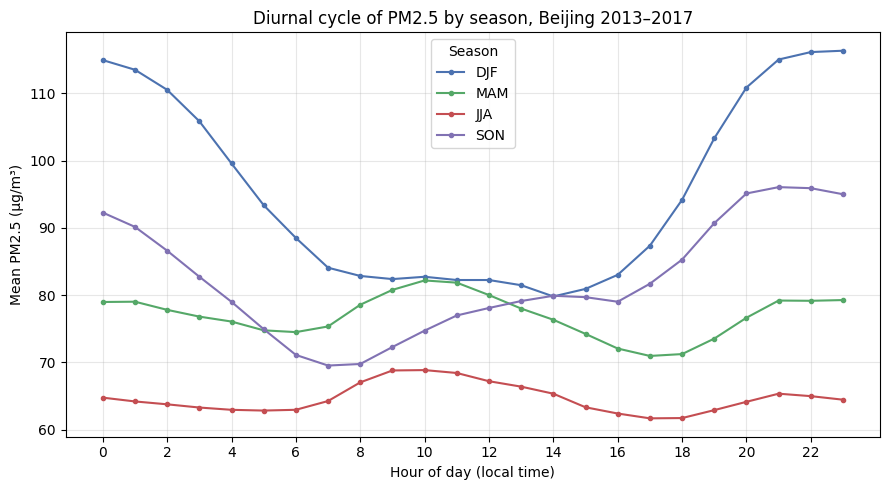

In [3]:
season_order = ["DJF", "MAM", "JJA", "SON"]
colors = {"DJF": "#4c72b0", "MAM": "#55a868", "JJA": "#c44e52", "SON": "#8172b3"}
diurnal = df.groupby(["season", "hour"])["PM2.5"].mean().unstack(0)[season_order]

fig, ax = plt.subplots(figsize=(9, 5))
for s in season_order:
    ax.plot(diurnal.index, diurnal[s], marker="o", ms=3, color=colors[s], label=s)
ax.set_xlabel("Hour of day (local time)")
ax.set_ylabel("Mean PM2.5 (µg/m³)")
ax.set_title("Diurnal cycle of PM2.5 by season, Beijing 2013–2017")
ax.set_xticks(range(0, 24, 2))
ax.legend(title="Season")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Monthly climatology

Both PM2.5 and SO₂ peak in the winter months and fall to a summer minimum, a pattern consistent with the coal-fired heating season and wintertime stagnation. SO₂ is drawn on its own axis because its magnitude is far smaller, but its seasonal shape tracks PM2.5 closely, an early sign that a shared combustion source drives much of the winter burden, which makes SO₂ a promising candidate for tracing coal-related controls in Part 2.

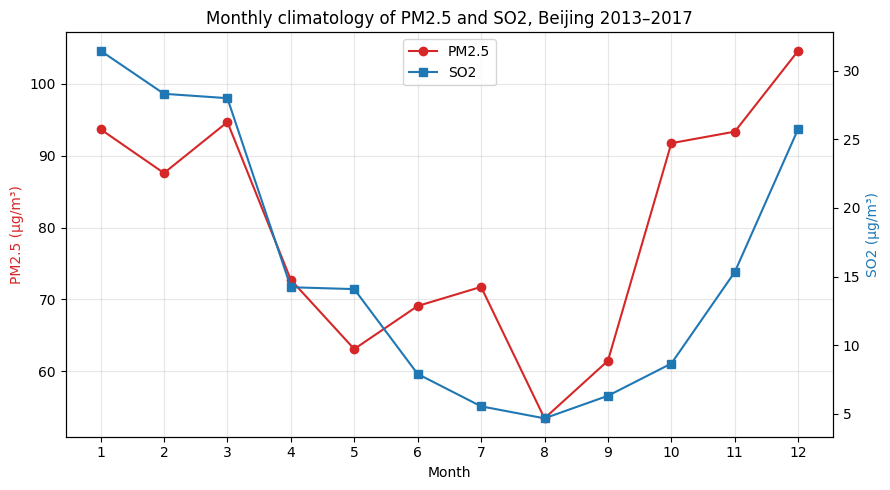

In [4]:
monthly = df.groupby("month")[["PM2.5", "SO2"]].mean()

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()
l1 = ax1.plot(monthly.index, monthly["PM2.5"], color="tab:red", marker="o", label="PM2.5")
l2 = ax2.plot(monthly.index, monthly["SO2"], color="tab:blue", marker="s", label="SO2")
ax1.set_xlabel("Month")
ax1.set_ylabel("PM2.5 (µg/m³)", color="tab:red")
ax2.set_ylabel("SO2 (µg/m³)", color="tab:blue")
ax1.set_title("Monthly climatology of PM2.5 and SO2, Beijing 2013–2017")
ax1.set_xticks(range(1, 13))
lines = l1 + l2
ax1.legend(lines, [l.get_label() for l in lines], loc="upper center")
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Hour × month structure

Collapsing the record onto an hour-by-month grid shows where the pollution actually concentrates: late-autumn and winter evenings and early mornings, when heating demand and a collapsed boundary layer coincide. The summer months stay low at every hour. This joint structure is exactly what a monthly or annual average smears together.

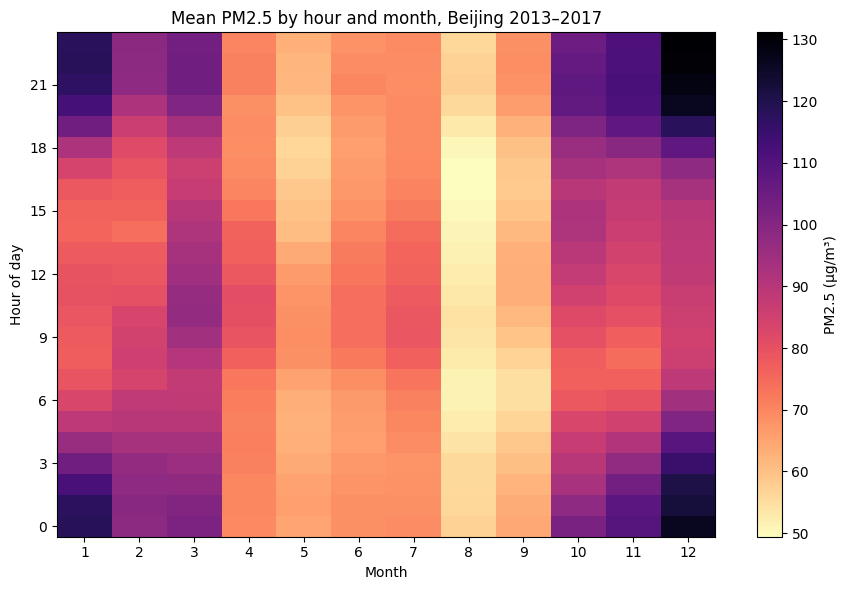

In [5]:
pivot = df.pivot_table(index="hour", columns="month", values="PM2.5", aggfunc="mean")

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.pcolormesh(pivot.columns, pivot.index, pivot.values, shading="auto", cmap="magma_r")
ax.set_xlabel("Month")
ax.set_ylabel("Hour of day")
ax.set_title("Mean PM2.5 by hour and month, Beijing 2013–2017")
ax.set_xticks(range(1, 13))
ax.set_yticks(range(0, 24, 3))
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("PM2.5 (µg/m³)")
plt.tight_layout()
plt.show()

## Seasonal distributions

The seasonal contrast lies less in the median than in the spread and the upper tail. The four seasons share a similar median (winter's is no higher than spring's), but winter's distribution is by far the widest, its interquartile range running from relatively clean hours in the teens to heavily polluted hours above 140, with a 95th percentile (the top whisker) above 300 µg/m³. The gap between the winter median and a mean near 95 shows that a relatively small number of severe haze episodes pulls the average upward. This is why seasonal or annual means are sensitive to how many extreme episodes occur in a given winter. Whiskers span the 5th–95th percentiles; individual extreme hours are omitted for legibility.

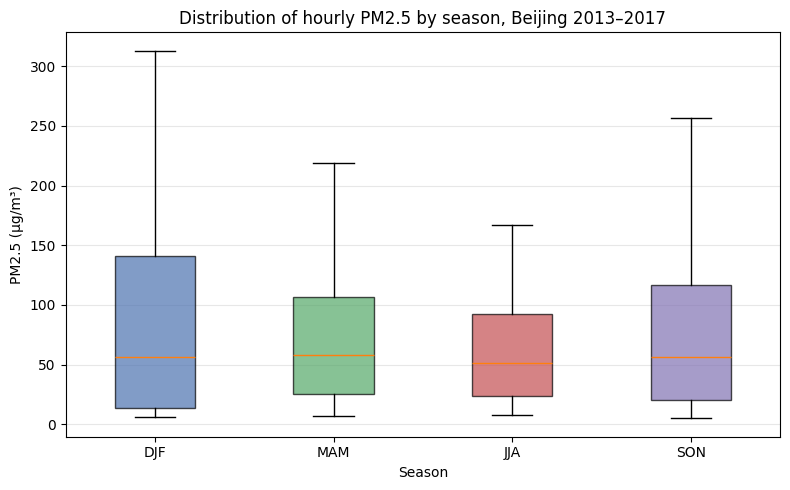

In [6]:
season_order = ["DJF", "MAM", "JJA", "SON"]
box_colors = ["#4c72b0", "#55a868", "#c44e52", "#8172b3"]
data = [df.loc[df["season"] == s, "PM2.5"].dropna() for s in season_order]

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(data, whis=(5, 95), showfliers=False, patch_artist=True)
for patch, c in zip(bp["boxes"], box_colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
ax.set_xticks(range(1, 5))
ax.set_xticklabels(season_order)
ax.set_xlabel("Season")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_title("Distribution of hourly PM2.5 by season, Beijing 2013–2017")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## Diurnal signatures: NO₂ versus SO₂

The daily cycles of the two gases run nearly out of phase, and the difference is informative about their sources. NO₂ falls to an afternoon minimum, consistent with a deep, well-mixed boundary layer and photochemical loss dispersing it, and climbs to an evening and overnight maximum as traffic emissions accumulate under a shallow nocturnal layer, with a smaller secondary bump at the morning commute. SO₂ does the opposite, peaking in the late morning, consistent with the overnight inversion breaking and combustion plumes from elevated sources mixing down to the surface. That SO₂ shows seasonal and diurnal behavior consistent with coal-related combustion is what makes it a promising trace of the coal controls examined in the next part, a candidate this notebook motivates rather than confirms.

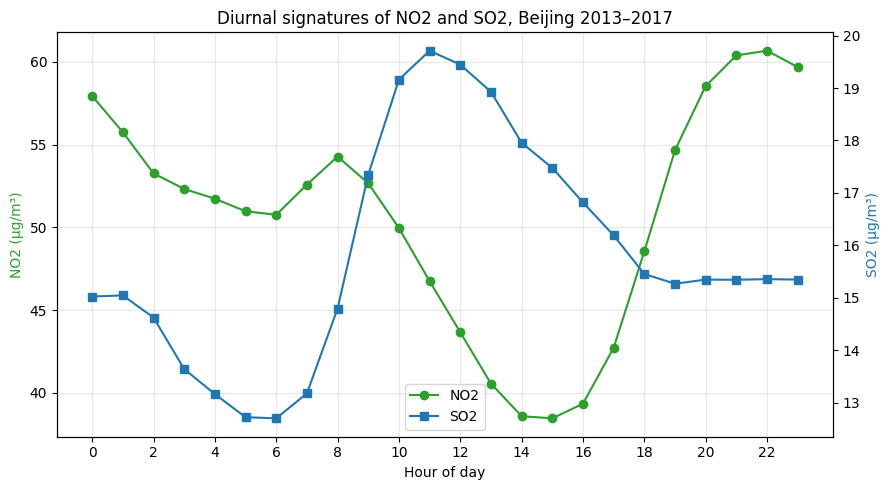

In [7]:
hourly = df.groupby("hour")[["NO2", "SO2"]].mean()

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()
l1 = ax1.plot(hourly.index, hourly["NO2"], color="tab:green", marker="o", label="NO2")
l2 = ax2.plot(hourly.index, hourly["SO2"], color="tab:blue", marker="s", label="SO2")
ax1.set_xlabel("Hour of day")
ax1.set_ylabel("NO2 (µg/m³)", color="tab:green")
ax2.set_ylabel("SO2 (µg/m³)", color="tab:blue")
ax1.set_title("Diurnal signatures of NO2 and SO2, Beijing 2013–2017")
ax1.set_xticks(range(0, 24, 2))
lines = l1 + l2
ax1.legend(lines, [l.get_label() for l in lines], loc="lower center")
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusion
Across the coverage summary, seasonal cycle, diurnal cycle, pollutant comparison, and distributional plots, one pattern is consistent: PM2.5 varies more within the year than between years. The winter diurnal range, about 80 to 116 µg/m³, is larger than the difference in full-year annual means from 2014 to 2016, which range from about 86 to 72 µg/m³. The seasonal swing is larger still. For that reason, raw annual averages are not very reliable on their own. They depend heavily on which months are included, especially at the edges of this dataset: 2013 begins in March, while 2017 includes only January and February. These two years cannot be compared cleanly with complete calendar years. Even the complete years are affected by a small number of severe winter haze episodes, which raise the winter mean to about 95 while the median remains much lower, around 56.

The pollutant cycles also suggest that the sources and atmospheric processes differ by pollutant. PM2.5 and SO₂ both peak in winter, which is consistent with a larger cold-season contribution from coal combustion. Over the day, NO₂ and SO₂ show almost opposite patterns: NO₂ is more closely tied to traffic and nighttime trapping, while SO₂ appears more consistent with late-morning mixing of combustion plumes. This makes SO₂ a useful candidate for testing the effects of coal-control policies in Part 2, although the climatology alone cannot establish that policy effect.

The next step is therefore to separate the trend from the seasonal cycle. Any trend in PM2.5 or SO₂ should be estimated from a deseasonalized series, because the raw signal is dominated by seasonal variation. It also needs to be checked against meteorology, since boundary-layer conditions and weather can change pollution levels from year to year without reflecting an emissions change. This notebook does not estimate or attribute the trend directly. By pooling the years together, it describes the average climatology; Parts 2 and 3 will isolate the time trend and test whether the observed changes can be attributed to policy rather than weather or sampling effects.